# Module 1: Load Data

In [2]:
import pandas as pd
import numpy as np
from google.colab import drive
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Mount Google Drive
drive.mount('/content/drive')

# Load the data
file_path = '/content/drive/My Drive/Thesis Data/Thesis_Main_Data.json'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Module 2: Descriptive Statistics

In [3]:
def load_and_check_data(file_path):
    """
    Load JSON data and perform initial checks

    Args:
        file_path: Path to the JSON file in Google Drive
    Returns:
        Processed DataFrame and initial statistics
    """
    print("Loading data...")

    # Read JSON file
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    print(f"\nTotal records loaded: {len(data)}")

    # Convert to DataFrame
    df = pd.DataFrame(data)

    # Basic information about the dataset
    print("\nDataset Overview:")
    print("-" * 50)
    print("\nDataFrame Info:")
    print(df.info())

    print("\nDataFrame Head:")
    print(df.head())

    # Check time range
    if 'createdAt' in df.columns:
        df['createdAt'] = pd.to_datetime(df['createdAt'])
        print("\nTime Range:")
        print(f"Earliest date: {df['createdAt'].min()}")
        print(f"Latest date: {df['createdAt'].max()}")
        print(f"Date range: {(df['createdAt'].max() - df['createdAt'].min()).days} days")

    # Check for missing values
    print("\nMissing Values:")
    print(df.isnull().sum())

    return df
df = load_and_check_data(file_path)

# Display basic engagement statistics
print("\nEngagement Statistics:")
print("-" * 50)
engagement_stats = {
    'Retweets': df['retweetCount'].describe(),
    'Likes': df['likeCount'].describe(),
    'Replies': df['replyCount'].describe(),
    'Quotes': df['quoteCount'].describe()
}

for metric, stats in engagement_stats.items():
    print(f"\n{metric}:")
    print(stats)

# Save the DataFrame for future use
df.to_pickle('/content/drive/My Drive/Thesis Data/processed_data.pkl')
print("\nProcessed data saved as pickle file for faster loading in future.")

Loading data...

Total records loaded: 132861

Dataset Overview:
--------------------------------------------------

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132861 entries, 0 to 132860
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   type                      132861 non-null  object
 1   id                        132861 non-null  object
 2   url                       132861 non-null  object
 3   twitterUrl                132861 non-null  object
 4   text                      132861 non-null  object
 5   fullText                  132861 non-null  object
 6   source                    132861 non-null  object
 7   retweetCount              132861 non-null  int64 
 8   replyCount                132861 non-null  int64 
 9   likeCount                 132861 non-null  int64 
 10  quoteCount                132861 non-null  int64 
 11  createdAt                 132861 non

<ipython-input-3-e3e008c1b43c>:32: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['createdAt'] = pd.to_datetime(df['createdAt'])



Time Range:
Earliest date: 2020-05-01 00:00:29+00:00
Latest date: 2021-04-30 23:42:56+00:00
Date range: 364 days

Missing Values:
type                             0
id                               0
url                              0
twitterUrl                       0
text                             0
fullText                         0
source                           0
retweetCount                     0
replyCount                       0
likeCount                        0
quoteCount                       0
createdAt                        0
lang                             0
bookmarkCount                    0
isReply                          0
conversationId                   0
possiblySensitive            59025
isPinned                         0
author                           0
extendedEntities                 0
card                             0
place                            0
entities                         0
isRetweet                        0
isQuote                      

# Module 3: Temporal Analysis

<ipython-input-12-3802f3346fd1>:47: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['createdAt'].dt.to_period('M')


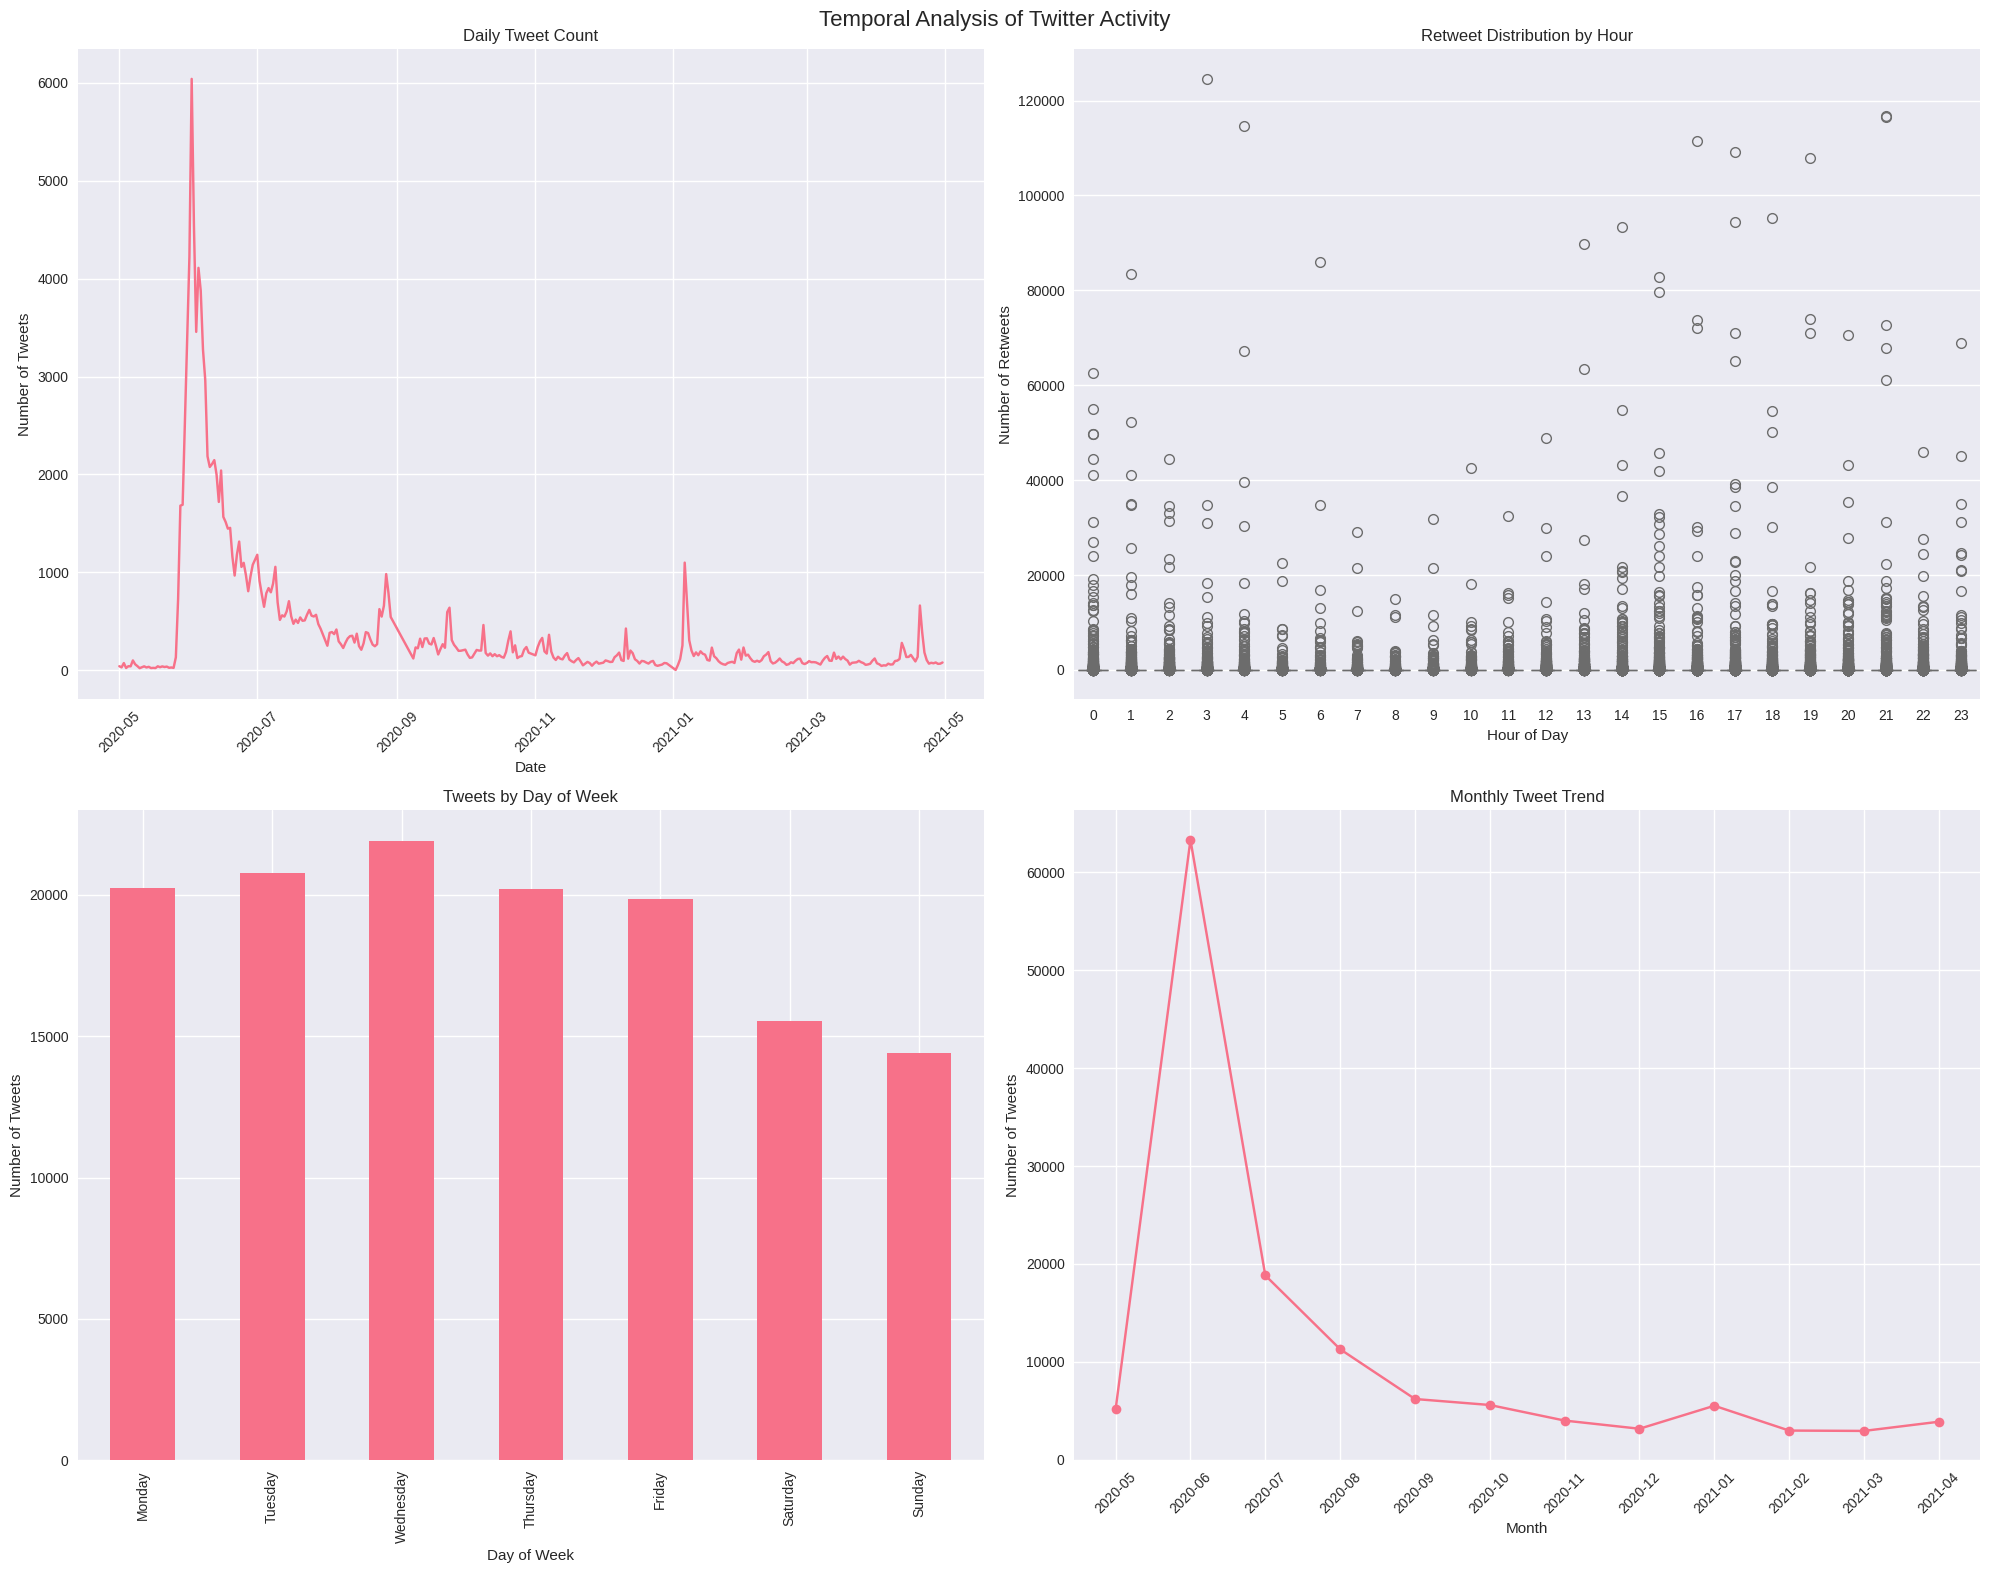

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Set style for better visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def create_temporal_analysis(df):
    """
    Create temporal analysis visualizations
    """
    # Create figure with multiple subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Temporal Analysis of Twitter Activity', fontsize=16)

    # 1. Daily tweet count
    df_daily = df.groupby(df['createdAt'].dt.date).size()
    axes[0,0].plot(df_daily.index, df_daily.values)
    axes[0,0].set_title('Daily Tweet Count')
    axes[0,0].set_xlabel('Date')
    axes[0,0].set_ylabel('Number of Tweets')
    axes[0,0].tick_params(axis='x', rotation=45)

    # 2. Hourly distribution
    df['hour'] = df['createdAt'].dt.hour
    sns.boxplot(data=df, x='hour', y='retweetCount', ax=axes[0,1])
    axes[0,1].set_title('Retweet Distribution by Hour')
    axes[0,1].set_xlabel('Hour of Day')
    axes[0,1].set_ylabel('Number of Retweets')

    # 3. Day of week analysis
    df['day_of_week'] = df['createdAt'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df['day_of_week'].value_counts().reindex(day_order)
    day_counts.plot(kind='bar', ax=axes[1,0])
    axes[1,0].set_title('Tweets by Day of Week')
    axes[1,0].set_xlabel('Day of Week')
    axes[1,0].set_ylabel('Number of Tweets')

    # 4. Monthly trend
    df['month'] = df['createdAt'].dt.to_period('M')
    monthly_counts = df.groupby('month').size()
    axes[1,1].plot(range(len(monthly_counts)), monthly_counts.values, marker='o')
    axes[1,1].set_title('Monthly Tweet Trend')
    axes[1,1].set_xlabel('Month')
    axes[1,1].set_ylabel('Number of Tweets')
    axes[1,1].set_xticks(range(len(monthly_counts)))
    axes[1,1].set_xticklabels(monthly_counts.index.astype(str), rotation=45)

    plt.tight_layout()
    return fig

# Load the data
df = pd.read_pickle('/content/drive/My Drive/Thesis Data/processed_data.pkl')

# Create and display visualizations
temporal_fig = create_temporal_analysis(df)

# Save figures
temporal_fig.savefig('/content/drive/My Drive/Thesis Data/temporal_analysis.png', dpi=300, bbox_inches='tight')

# Module 4: Retweet Statistics


Retweet Statistics:
--------------------------------------------------
Total number of retweets: 18,035,422
Average retweets per tweet: 135.75
Median retweets per tweet: 13.00
Maximum retweets for a single tweet: 124,574

Retweet Distribution:
retweetCount
1-10        55263
11-100      62796
101-1000    12497
1000+        2291
Name: count, dtype: int64


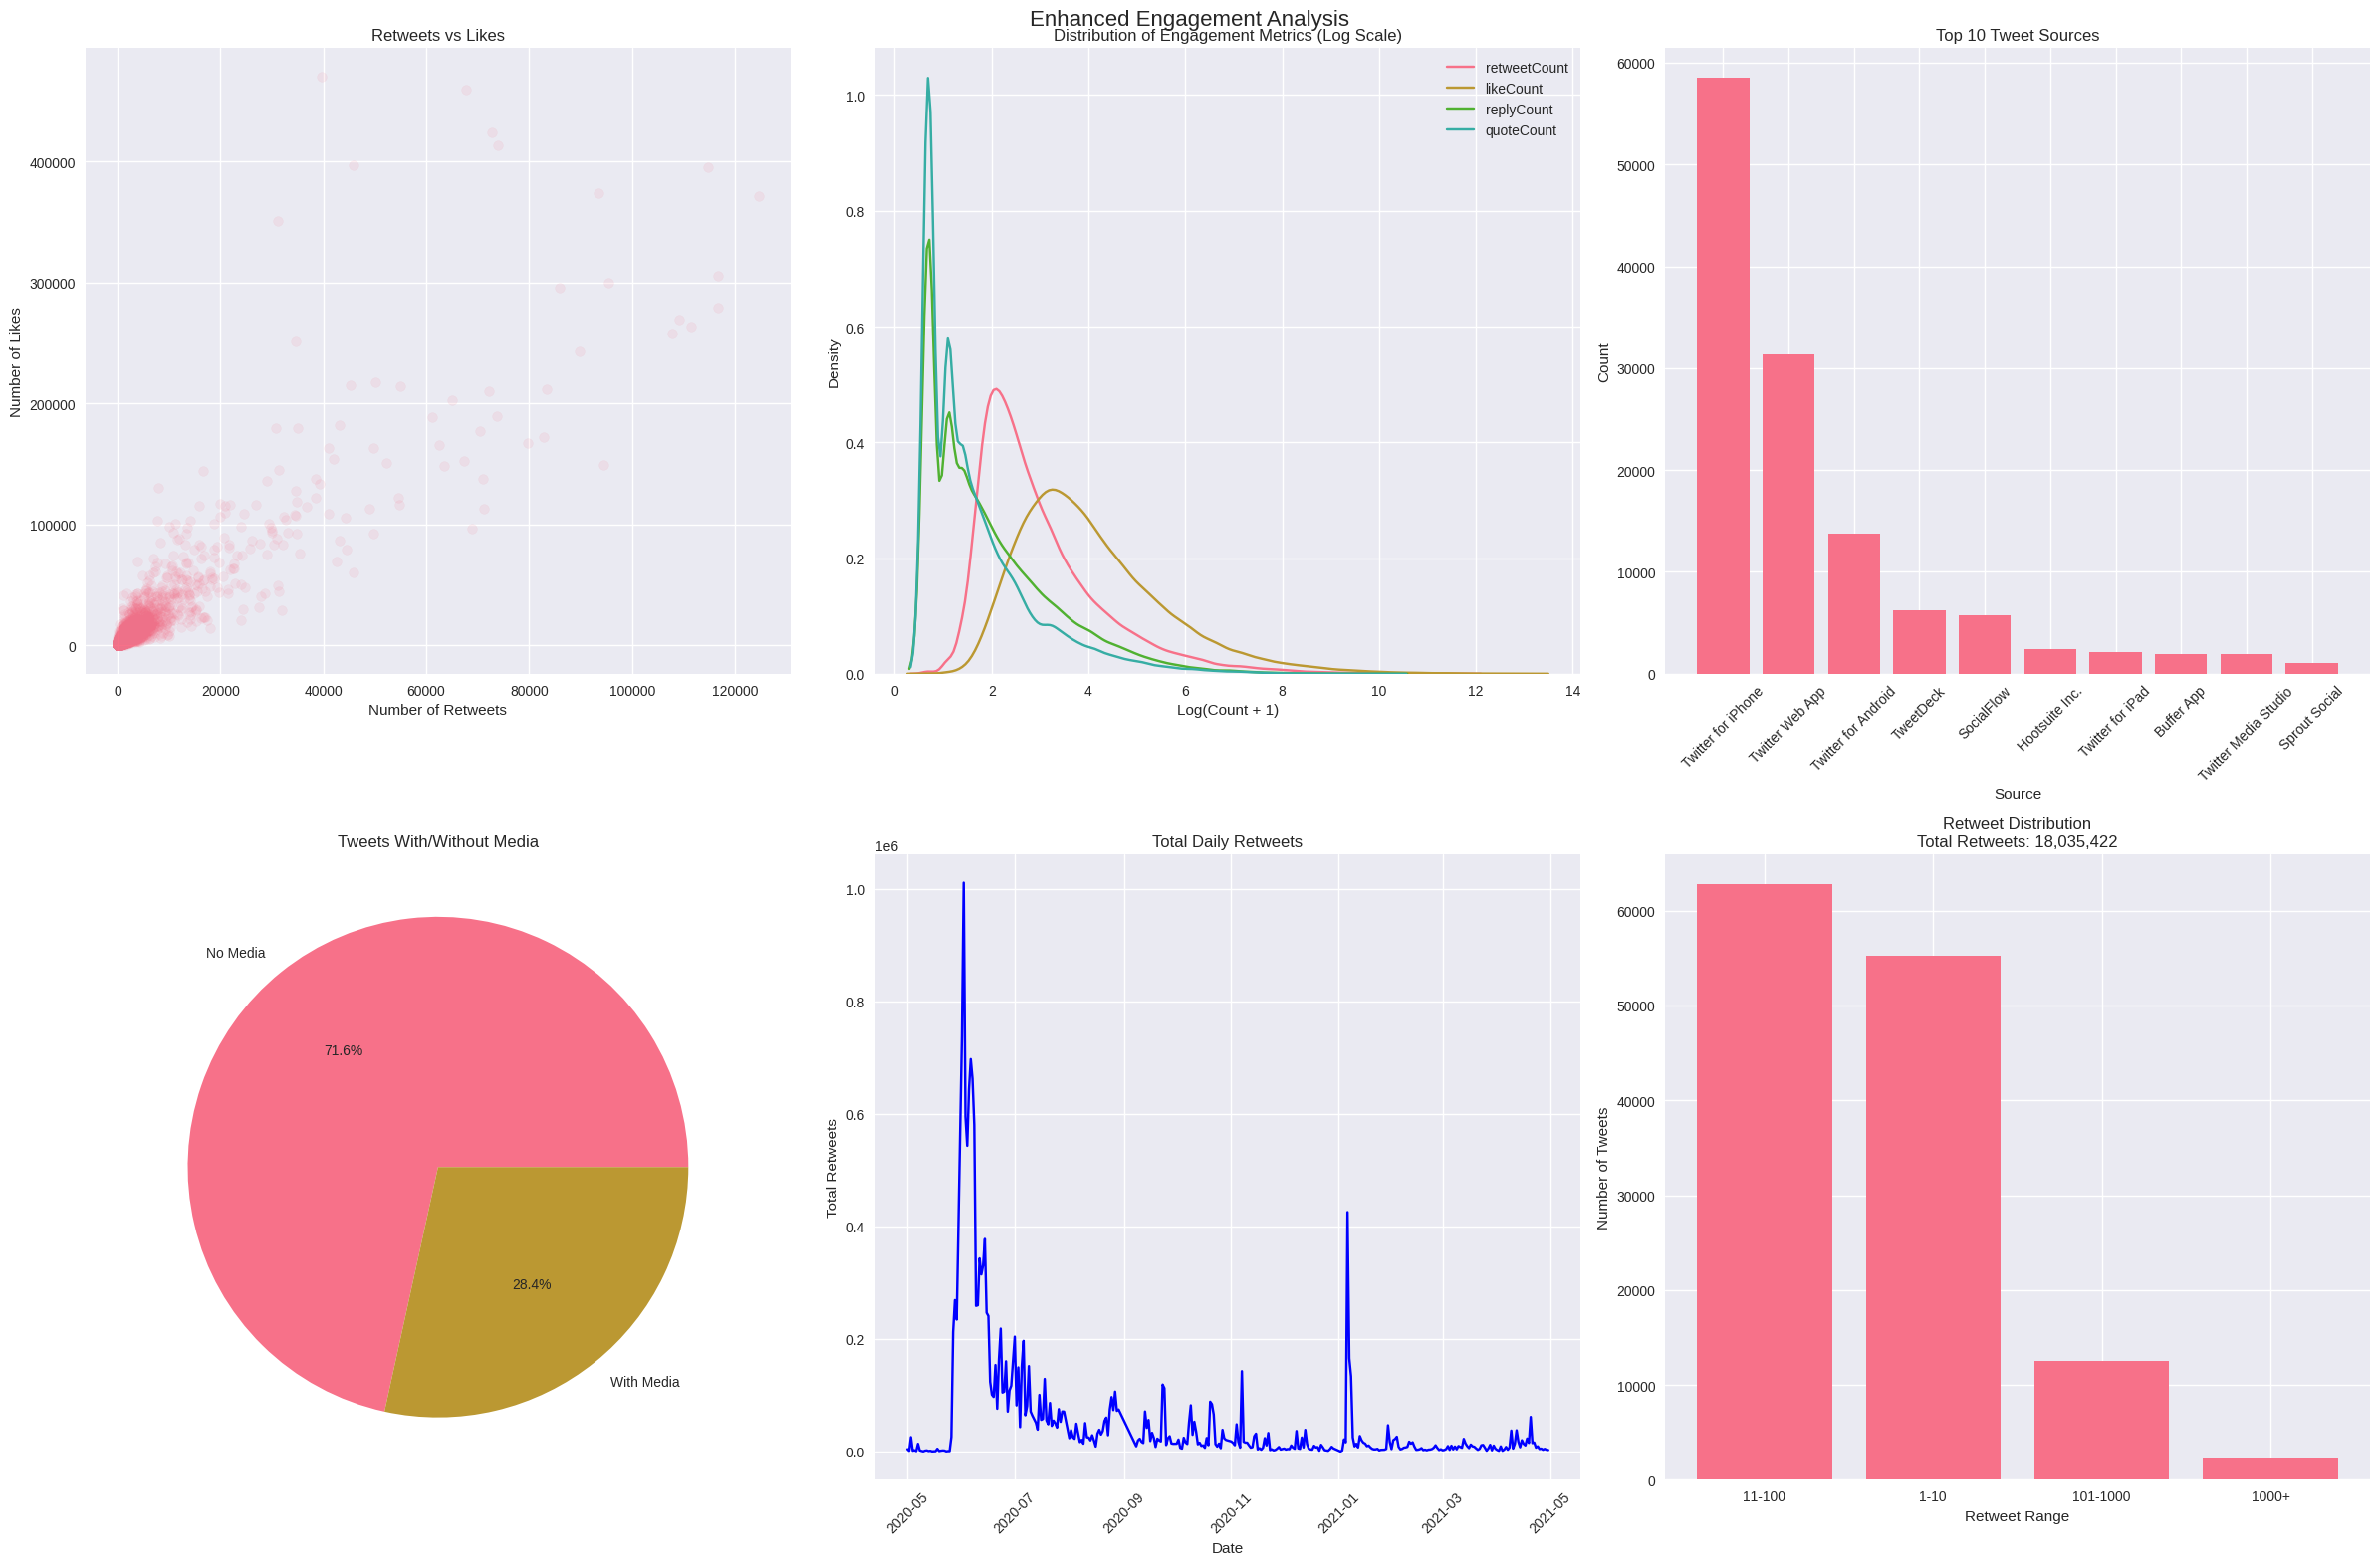

In [11]:
def create_enhanced_engagement_analysis(df):
    """
    Create enhanced engagement analysis visualizations including total retweets
    """
    # Create a figure with 2x3 subplots to accommodate the new metric
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(2, 3)
    fig.suptitle('Enhanced Engagement Analysis', fontsize=16)

    # 1. Retweet vs Like correlation (top left)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(df['retweetCount'], df['likeCount'], alpha=0.1)
    ax1.set_title('Retweets vs Likes')
    ax1.set_xlabel('Number of Retweets')
    ax1.set_ylabel('Number of Likes')

    # 2. Engagement distribution (log scale) (top middle)
    ax2 = fig.add_subplot(gs[0, 1])
    metrics = ['retweetCount', 'likeCount', 'replyCount', 'quoteCount']
    for metric in metrics:
        sns.kdeplot(data=df[df[metric] > 0][metric].apply(np.log1p),
                   label=metric, ax=ax2)
    ax2.set_title('Distribution of Engagement Metrics (Log Scale)')
    ax2.set_xlabel('Log(Count + 1)')
    ax2.legend()

    # 3. Source analysis (top right)
    ax3 = fig.add_subplot(gs[0, 2])
    top_sources = df['source'].value_counts().head(10)
    ax3.bar(range(len(top_sources)), top_sources.values)
    ax3.set_title('Top 10 Tweet Sources')
    ax3.set_xlabel('Source')
    ax3.set_ylabel('Count')
    ax3.set_xticks(range(len(top_sources)))
    ax3.set_xticklabels(top_sources.index, rotation=45)

    # 4. Media type analysis (bottom left)
    ax4 = fig.add_subplot(gs[1, 0])
    media_counts = df['media'].apply(lambda x: len(x) > 0).value_counts()
    ax4.pie(media_counts.values, labels=['No Media', 'With Media'],
            autopct='%1.1f%%')
    ax4.set_title('Tweets With/Without Media')

    # 5. Total Retweets over time (bottom middle)
    ax5 = fig.add_subplot(gs[1, 1])
    # Group by date and sum retweets
    daily_retweets = df.groupby(df['createdAt'].dt.date)['retweetCount'].sum()
    ax5.plot(daily_retweets.index, daily_retweets.values, 'b-')
    ax5.set_title('Total Daily Retweets')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Total Retweets')
    ax5.tick_params(axis='x', rotation=45)

    # 6. Retweet Distribution Analysis (bottom right)
    ax6 = fig.add_subplot(gs[1, 2])
    total_retweets = df['retweetCount'].sum()
    retweet_categories = pd.cut(df['retweetCount'],
                              bins=[0, 10, 100, 1000, float('inf')],
                              labels=['1-10', '11-100', '101-1000', '1000+'])
    retweet_dist = retweet_categories.value_counts()
    ax6.bar(retweet_dist.index, retweet_dist.values)
    ax6.set_title(f'Retweet Distribution\nTotal Retweets: {total_retweets:,}')
    ax6.set_xlabel('Retweet Range')
    ax6.set_ylabel('Number of Tweets')

    plt.tight_layout()
    return fig

# Load the data
df = pd.read_pickle('/content/drive/My Drive/Thesis Data/processed_data.pkl')

# Create enhanced visualization
enhanced_engagement_fig = create_enhanced_engagement_analysis(df)

# Save figure
enhanced_engagement_fig.savefig('/content/drive/My Drive/Thesis Data/enhanced_engagement_analysis.png',
                              dpi=300, bbox_inches='tight')

# Print some additional statistics about retweets
print("\nRetweet Statistics:")
print("-" * 50)
print(f"Total number of retweets: {df['retweetCount'].sum():,}")
print(f"Average retweets per tweet: {df['retweetCount'].mean():.2f}")
print(f"Median retweets per tweet: {df['retweetCount'].median():.2f}")
print(f"Maximum retweets for a single tweet: {df['retweetCount'].max():,}")
print("\nRetweet Distribution:")
retweet_ranges = [0, 10, 100, 1000, float('inf')]
retweet_labels = ['1-10', '11-100', '101-1000', '1000+']
retweet_dist = pd.cut(df['retweetCount'], bins=retweet_ranges, labels=retweet_labels)
print(retweet_dist.value_counts().sort_index())

# Module 5: Content Distribution


Text Content Statistics:
--------------------------------------------------
Average tweet length: 181.6 characters

Top 10 Hashtags:
#blacklivesmatter: 6321
#blm: 1947
#black_lives_matter: 1314
#blackouttuesday: 806
#georgefloyd: 620
#endsars: 348
#justiceforgeorgefloyd: 261
#defundthepolice: 250
#breonnataylor: 239
#dc: 200

Top 10 Words (excluding stop words):
black: 156602
lives: 146669
matter: 143895
people: 18295
police: 13083
movement: 12376
white: 11045
amp: 10812
support: 9179
say: 8256


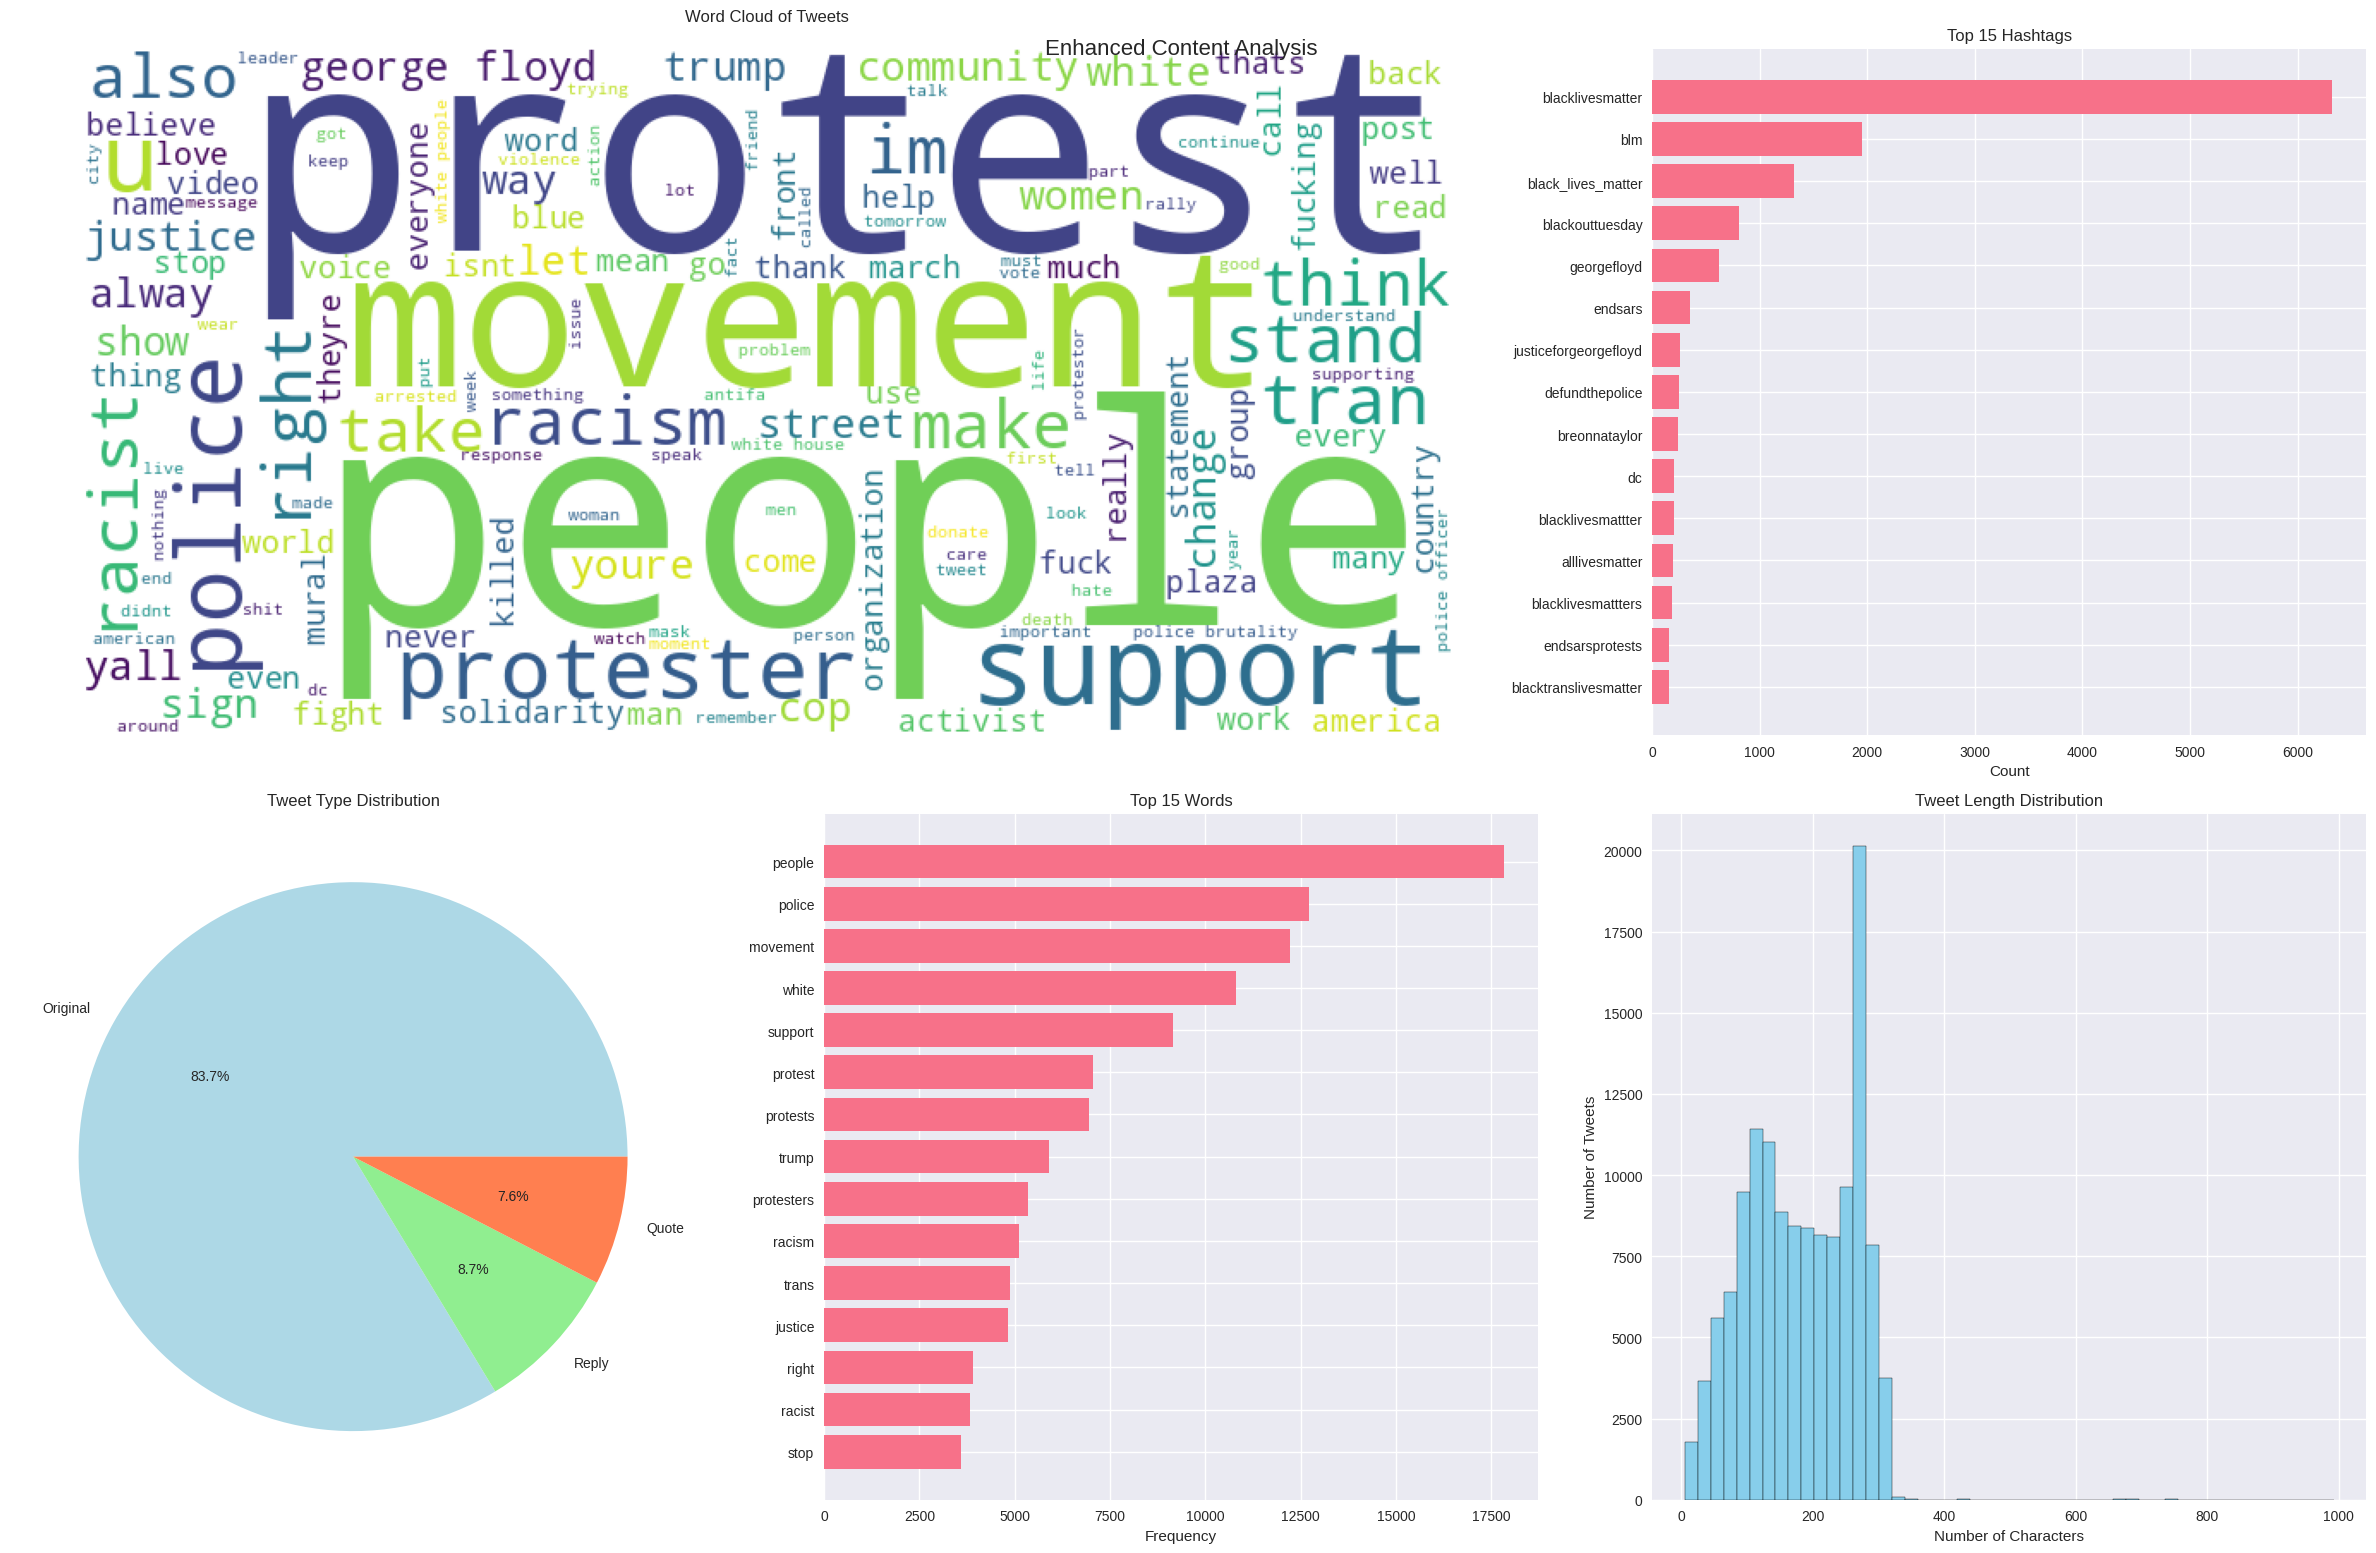

In [22]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from collections import Counter
import re

# Download required NLTK data first
nltk.download('stopwords', quiet=True)

def simple_tokenize(text):
    """
    Simple tokenization function that splits on whitespace and removes punctuation
    """
    # Remove URLs, mentions, and special characters
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|\#\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return [word.lower() for word in text.split() if len(word) > 2]

def create_enhanced_content_analysis(df):
    """
    Create enhanced content analysis with text mining and word cloud
    """
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(2, 3)
    fig.suptitle('Enhanced Content Analysis', fontsize=16, y=0.95)

    # Prepare text data
    all_text = ' '.join(df['text'].values)

    # Custom stop words
    stop_words = set(stopwords.words('english'))
    custom_stops = {'https', 't.co', 'rt', 'amp', 'co', 'like', 'twitter',
                   'black', 'lives', 'matter', 'blm', 'via', 'get', 'one',
                   'would', 'say', 'said', 'says', 'going', 'now', 'will', 'day',
                    'dont', 'today', 'still', 'new', "need", "cant",
                    "know", "please", "see", "saying", "time","want"} # Remove common terms in dataset
    stop_words.update(custom_stops)

    # Clean text
    def clean_text(text):
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'@\w+|\#\w+', '', text)
        text = re.sub(r'[^\w\s]', '', text)
        text = text.lower()
        return text

    cleaned_text = clean_text(all_text)

    # 1. Word Cloud (top left)
    ax1 = fig.add_subplot(gs[0, :2])
    wordcloud = WordCloud(width=800, height=400,
                         background_color='white',
                         stopwords=stop_words,
                         min_font_size=10).generate(cleaned_text)

    ax1.imshow(wordcloud)
    ax1.axis('off')
    ax1.set_title('Word Cloud of Tweets', pad=20)

    # 2. Top hashtags analysis (top right)
    ax2 = fig.add_subplot(gs[0, 2])
    hashtags = []
    for text in df['text']:
        hashtags.extend(re.findall(r'#(\w+)', text.lower()))

    top_hashtags = Counter(hashtags).most_common(15)
    ax2.barh([tag[0] for tag in top_hashtags][::-1],
             [count for tag, count in top_hashtags][::-1])
    ax2.set_title('Top 15 Hashtags')
    ax2.set_xlabel('Count')

    # 3. Tweet type distribution (bottom left)
    ax3 = fig.add_subplot(gs[1, 0])
    tweet_types = []
    for _, row in df.iterrows():
        if row['isReply']:
            tweet_types.append('Reply')
        elif row['isQuote']:
            tweet_types.append('Quote')
        elif row['isRetweet']:
            tweet_types.append('Retweet')
        else:
            tweet_types.append('Original')

    type_counts = Counter(tweet_types)
    colors = ['lightblue', 'lightgreen', 'coral', 'lightgray']
    ax3.pie(type_counts.values(), labels=type_counts.keys(),
            autopct='%1.1f%%', colors=colors)
    ax3.set_title('Tweet Type Distribution')

    # 4. Word frequency analysis (bottom middle)
    ax4 = fig.add_subplot(gs[1, 1])
    # Use simple tokenization
    words = simple_tokenize(cleaned_text)
    words = [word for word in words if word not in stop_words]
    word_freq = Counter(words).most_common(15)

    ax4.barh([word[0] for word in word_freq][::-1],
             [count for word, count in word_freq][::-1])
    ax4.set_title('Top 15 Words')
    ax4.set_xlabel('Frequency')

    # 5. Tweet length distribution (bottom right)
    ax5 = fig.add_subplot(gs[1, 2])
    tweet_lengths = df['text'].str.len()
    ax5.hist(tweet_lengths, bins=50, color='skyblue', edgecolor='black')
    ax5.set_title('Tweet Length Distribution')
    ax5.set_xlabel('Number of Characters')
    ax5.set_ylabel('Number of Tweets')

    plt.tight_layout()
    return fig

# Load the data
df = pd.read_pickle('/content/drive/My Drive/Thesis Data/processed_data.pkl')

# Create enhanced visualization
enhanced_content_fig = create_enhanced_content_analysis(df)

# Save figure
enhanced_content_fig.savefig('/content/drive/My Drive/Thesis Data/enhanced_content_analysis.png',
                           dpi=300, bbox_inches='tight')

# Print additional text statistics
print("\nText Content Statistics:")
print("-" * 50)
# Calculate average tweet length
avg_length = df['text'].str.len().mean()
print(f"Average tweet length: {avg_length:.1f} characters")

# Get most common hashtags
hashtags = []
for text in df['text']:
    hashtags.extend(re.findall(r'#(\w+)', text.lower()))
print("\nTop 10 Hashtags:")
for tag, count in Counter(hashtags).most_common(10):
    print(f"#{tag}: {count}")

# Get most common words
all_text = ' '.join(df['text'].values)
words = simple_tokenize(all_text)
stop_words = set(stopwords.words('english'))
words = [word for word in words if word not in stop_words]
print("\nTop 10 Words (excluding stop words):")
for word, count in Counter(words).most_common(10):
    print(f"{word}: {count}")

# Module 5: Engagement Distribution

<ipython-input-24-f43c73a29b43>:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unique_authors['author_followers'] = unique_authors['author'].apply(lambda x: x.get('followers', 0))
<ipython-input-24-f43c73a29b43>:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  engagement_by_length = df.groupby(lengths)['retweetCount'].mean()



Interaction Analysis Summary:
--------------------------------------------------

Total Unique Authors: 64,872

Author Distribution by Category:
Small (<10K): 56,686 authors (42.7%)
Medium (10K-100K): 39,671 authors (29.9%)
Large (100K-1M): 24,641 authors (18.5%)
Mega (1M+): 11,863 authors (8.9%)

Average Engagement by Author Category:

retweetCount:
Small (<10K): 83.5
Medium (10K-100K): 76.6
Large (100K-1M): 193.7
Mega (1M+): 462.8

likeCount:
Small (<10K): 266.0
Medium (10K-100K): 262.2
Large (100K-1M): 716.8
Mega (1M+): 1961.0

Visualization saved as 'interaction_analysis.png'


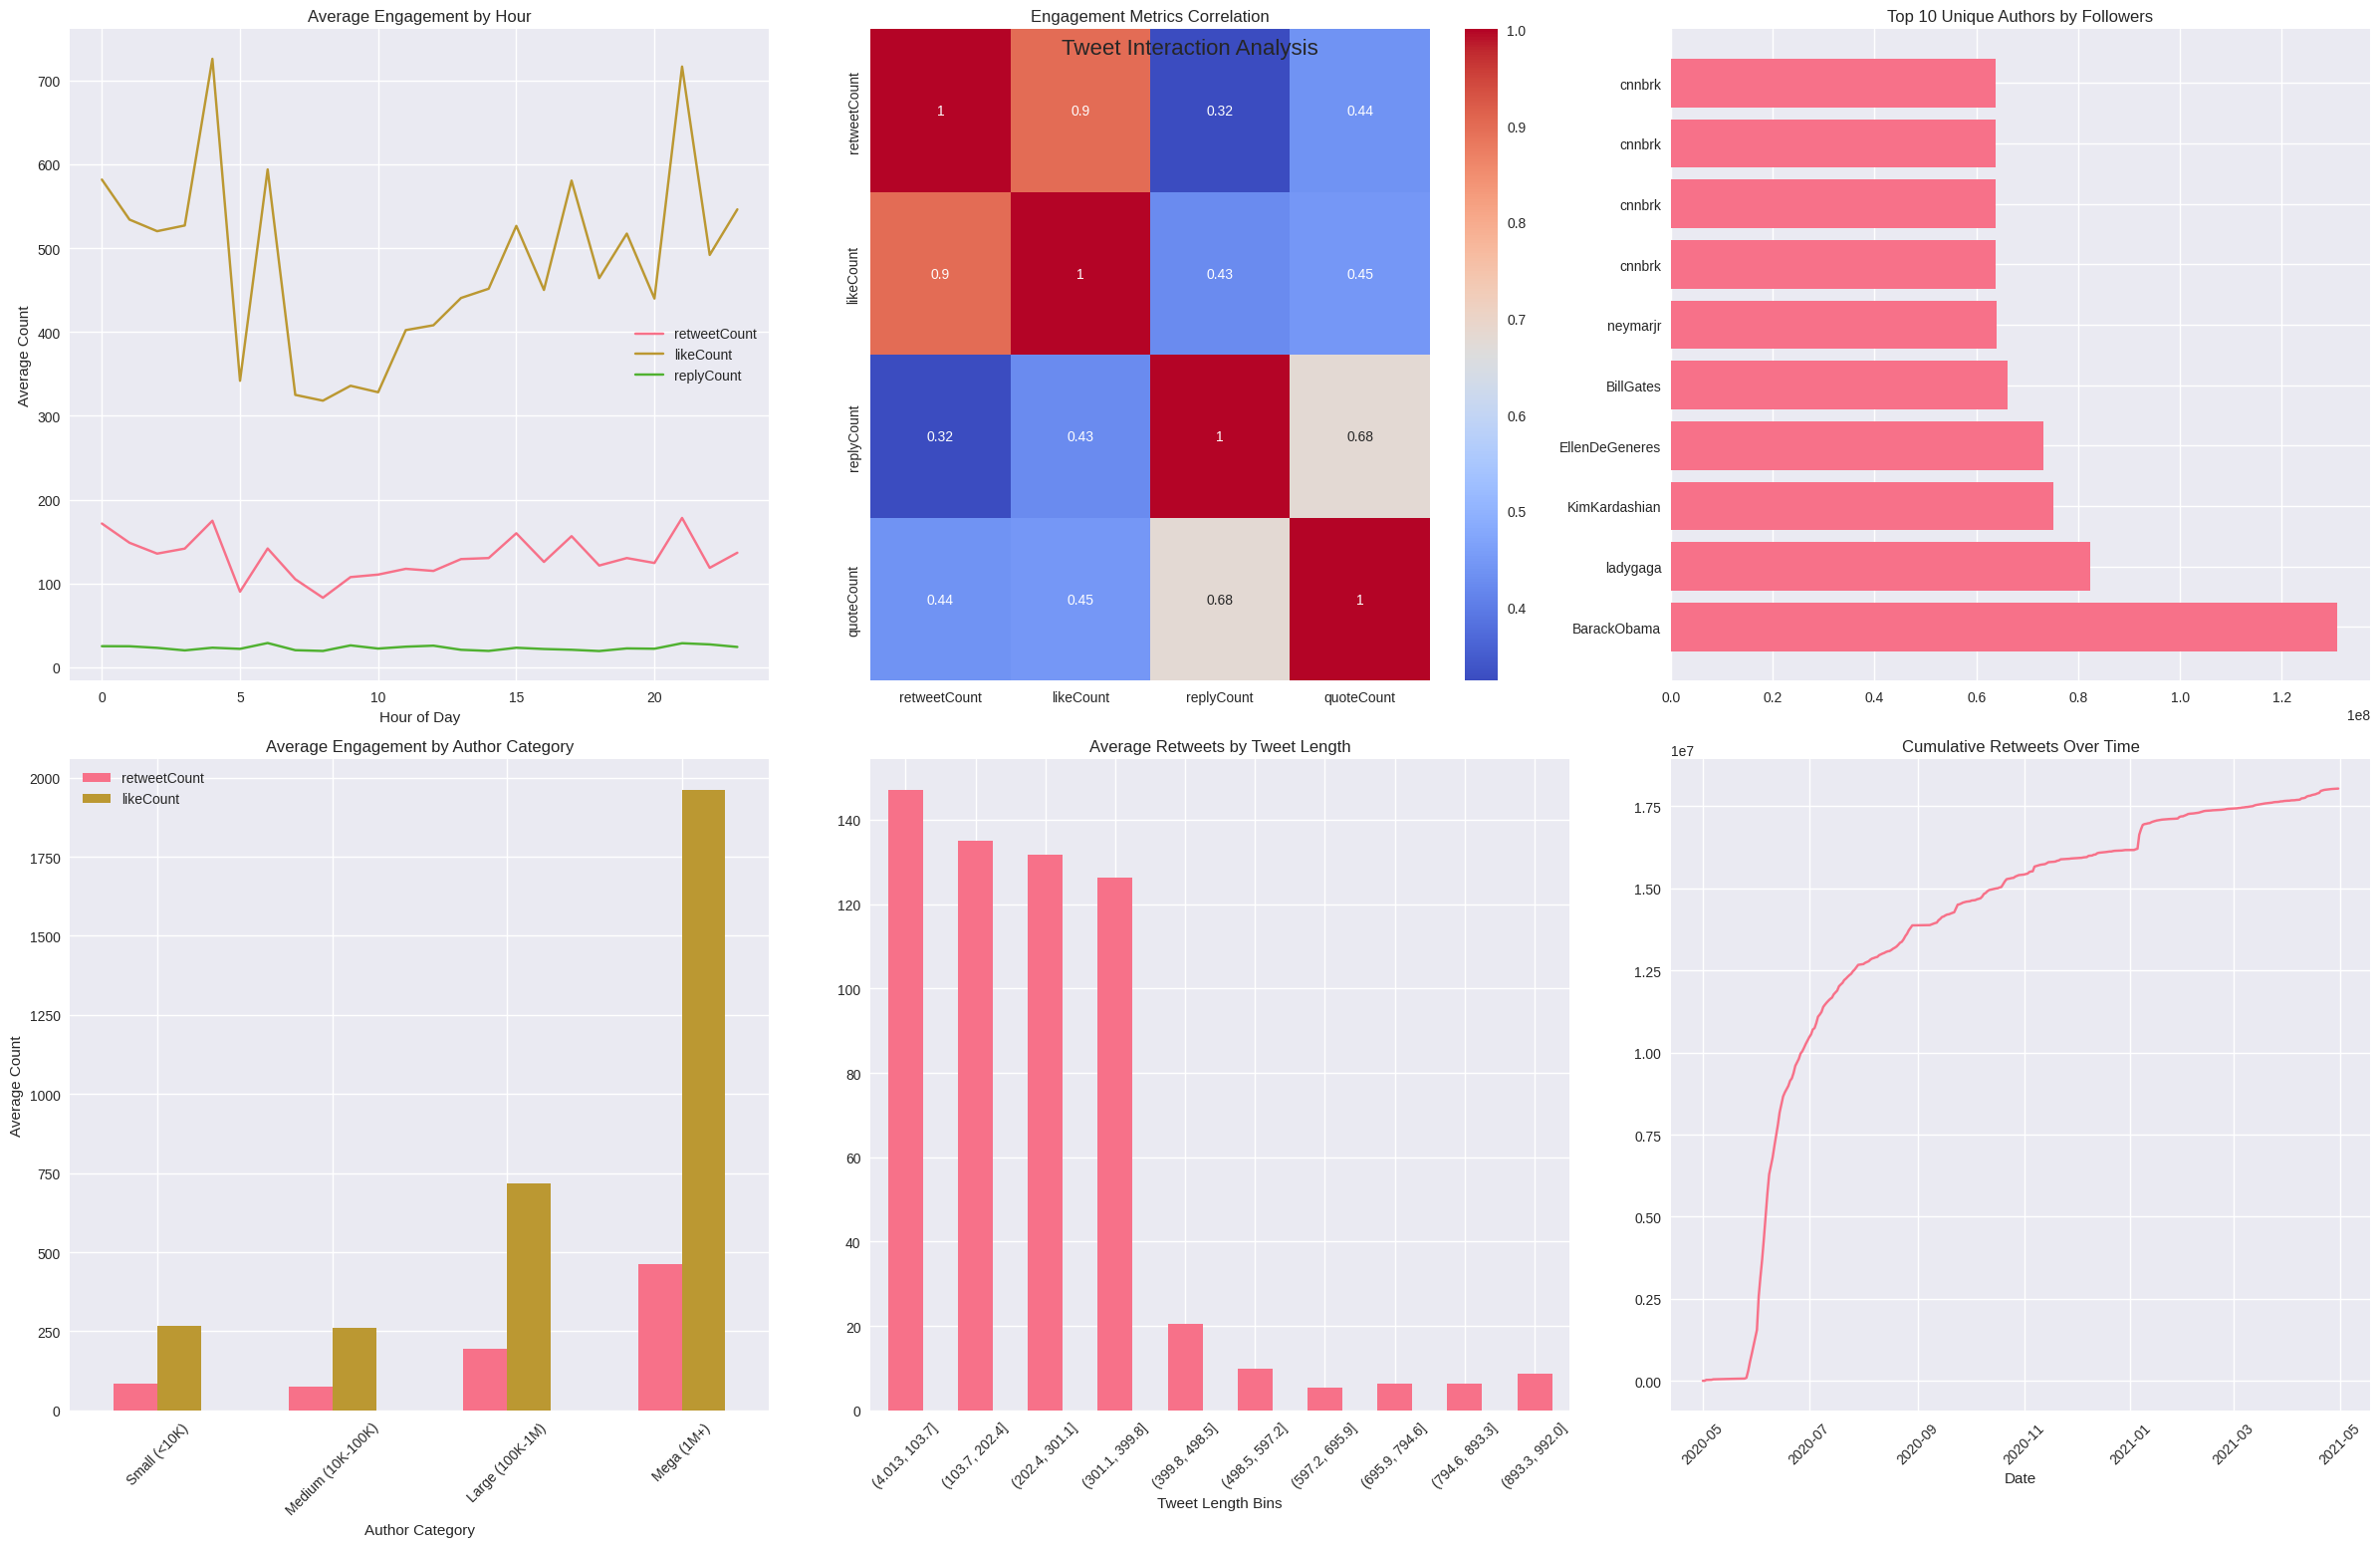

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def create_interaction_analysis(df):
    """
    Analyze tweet interactions and engagement patterns with improved metrics
    """
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(2, 3)
    fig.suptitle('Tweet Interaction Analysis', fontsize=16, y=0.95)

    # 1. Engagement vs Time of Day
    ax1 = fig.add_subplot(gs[0, 0])
    df['hour'] = df['createdAt'].dt.hour
    hourly_engagement = df.groupby('hour').agg({
        'retweetCount': 'mean',
        'likeCount': 'mean',
        'replyCount': 'mean'
    })
    hourly_engagement.plot(ax=ax1)
    ax1.set_title('Average Engagement by Hour')
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Average Count')
    ax1.legend()

    # 2. Engagement Correlation Heatmap
    ax2 = fig.add_subplot(gs[0, 1])
    engagement_cols = ['retweetCount', 'likeCount', 'replyCount', 'quoteCount']
    correlation = df[engagement_cols].corr()
    sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=ax2)
    ax2.set_title('Engagement Metrics Correlation')

    # 3. Top Influencers (by follower count) - With Deduplication
    ax3 = fig.add_subplot(gs[0, 2])
    # Get unique authors by taking the first occurrence
    unique_authors = df.drop_duplicates(subset=['author'], keep='first')
    # Extract follower counts
    unique_authors['author_followers'] = unique_authors['author'].apply(lambda x: x.get('followers', 0))
    # Get top 10 unique authors
    top_authors = unique_authors.nlargest(10, 'author_followers')

    ax3.barh(range(10), top_authors['author_followers'])
    ax3.set_yticks(range(10))
    ax3.set_yticklabels(top_authors['author'].apply(lambda x: x.get('userName', '')))
    ax3.set_title('Top 10 Unique Authors by Followers')

    # 4. Engagement by Author Category (replacing engagement rate)
    ax4 = fig.add_subplot(gs[1, 0])
    # Categorize authors by follower count
    df['author_category'] = df['author'].apply(lambda x:
        'Mega (1M+)' if x.get('followers', 0) >= 1000000 else
        'Large (100K-1M)' if x.get('followers', 0) >= 100000 else
        'Medium (10K-100K)' if x.get('followers', 0) >= 10000 else
        'Small (<10K)')

    engagement_by_category = df.groupby('author_category').agg({
        'retweetCount': 'mean',
        'likeCount': 'mean'
    }).reindex(['Small (<10K)', 'Medium (10K-100K)', 'Large (100K-1M)', 'Mega (1M+)'])

    engagement_by_category.plot(kind='bar', ax=ax4)
    ax4.set_title('Average Engagement by Author Category')
    ax4.set_xlabel('Author Category')
    ax4.set_ylabel('Average Count')
    ax4.legend()
    ax4.tick_params(axis='x', rotation=45)

    # 5. Content Length vs Engagement
    ax5 = fig.add_subplot(gs[1, 1])
    df['text_length'] = df['text'].str.len()
    lengths = pd.cut(df['text_length'], bins=10)
    engagement_by_length = df.groupby(lengths)['retweetCount'].mean()
    engagement_by_length.plot(kind='bar', ax=ax5)
    ax5.set_title('Average Retweets by Tweet Length')
    ax5.set_xlabel('Tweet Length Bins')
    ax5.tick_params(axis='x', rotation=45)

    # 6. Cumulative Engagement Over Time
    ax6 = fig.add_subplot(gs[1, 2])
    df['date'] = df['createdAt'].dt.date
    daily_engagement = df.groupby('date')['retweetCount'].sum().cumsum()
    daily_engagement.plot(ax=ax6)
    ax6.set_title('Cumulative Retweets Over Time')
    ax6.set_xlabel('Date')
    ax6.tick_params(axis='x', rotation=45)

    plt.tight_layout()

    # Prepare return statistics
    stats = {
        'unique_authors': len(df['author'].apply(lambda x: x.get('userName', '')).unique()),
        'top_authors': top_authors[['author_followers']].to_dict(),
        'engagement_by_category': engagement_by_category.to_dict(),
        'daily_engagement': daily_engagement.to_dict()
    }

    return fig, df, stats

# Load the data
df = pd.read_pickle('/content/drive/My Drive/Thesis Data/processed_data.pkl')

# Create and save interaction analysis
interaction_fig, processed_df, stats = create_interaction_analysis(df)
interaction_fig.savefig('/content/drive/My Drive/Thesis Data/interaction_analysis.png',
                       dpi=300, bbox_inches='tight')

# Print interaction statistics
print("\nInteraction Analysis Summary:")
print("-" * 50)

# Overall statistics
print(f"\nTotal Unique Authors: {stats['unique_authors']:,}")

# Author category distribution
author_cats = processed_df['author_category'].value_counts()
print("\nAuthor Distribution by Category:")
for cat, count in author_cats.items():
    print(f"{cat}: {count:,} authors ({count/len(processed_df)*100:.1f}%)")

# Top engagement statistics by category
print("\nAverage Engagement by Author Category:")
engagement_stats = stats['engagement_by_category']
for category in ['retweetCount', 'likeCount']:
    print(f"\n{category}:")
    for cat, value in engagement_stats[category].items():
        print(f"{cat}: {value:.1f}")

print("\nVisualization saved as 'interaction_analysis.png'")
